## Problem Statement
Customer retention is declining and management wants to understand why and how to improve repeat purchases.

In [65]:
#Importing libraries

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

file_orders = r"/home/d53f6b8c-e65b-4250-8775-ba849cc08f9b/Retail Analytics_Customer Retention/Online Retail_raw data.xlsx"
file_analysis = r"/home/d53f6b8c-e65b-4250-8775-ba849cc08f9b/Retail Analytics_Customer Retention/Online Retail_transformed.xlsx"


In [63]:
#Reading data from excel to dataframe
df_orders = pd.read_excel(file_orders)

In [49]:
# Basic data check
print("Initial Shape:", df_orders.shape)
print("\nNull values:\n", df_orders.isnull().sum())

Initial Shape: (541909, 8)

Null values:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [50]:
#Data Cleaning
# Drop rows where CustomerID is missing (critical for customer-level analysis)
df_orders = df_orders.dropna(subset=['CustomerID']).copy()

# Convert data types
df_orders['InvoiceDate'] = pd.to_datetime(df_orders['InvoiceDate'])  # keep datetime (important)
df_orders['CustomerID'] = df_orders['CustomerID'].astype('Int64').astype('string')

# Filter data till Nov 30, 2011 (exclude incomplete December)
cutoff_date = pd.Timestamp('2011-12-01')
df_orders = df_orders[df_orders['InvoiceDate'] < cutoff_date].copy()

print("\nShape after cleaning:", df_orders.shape)


Shape after cleaning: (389168, 8)


In [51]:
#Remove Duplicates
rows_before = df_orders.shape[0]

df_orders = df_orders.drop_duplicates().copy()

print("\nDuplicates removed:", rows_before - df_orders.shape[0])


Duplicates removed: 4946


In [52]:
#Handle Returns
# Identify returns (negative quantity)
df_orders['IsReturn'] = df_orders['Quantity'] < 0

# Separate sale and return quantities
df_orders['SaleQuantity'] = df_orders['Quantity'].clip(lower=0)
df_orders['ReturnQuantity'] = df_orders['Quantity'].clip(upper=0).abs()

print("\nTotal return transactions:", df_orders['IsReturn'].sum())


Total return transactions: 8516


In [53]:
#Split Sales & Returns
df_sales = df_orders[~df_orders['IsReturn']].copy()
df_returns = df_orders[df_orders['IsReturn']].copy()

#Revenue Calculation
df_sales['TotalSalesAmount'] = df_sales['SaleQuantity'] * df_sales['UnitPrice']
df_returns['TotalReturnAmount'] = df_returns['ReturnQuantity'] * df_returns['UnitPrice']

df_return_values = (
    df_returns.groupby('CustomerID', as_index=False)['TotalReturnAmount'].sum()
)


In [55]:
#Define Reference Date
ref_date = df_orders['InvoiceDate'].max() + pd.Timedelta(days=1)

#RFM Calculation
df_rfm = (
    df_sales.groupby('CustomerID')
    .agg(
        Recency=('InvoiceDate', lambda x: (ref_date - x.max()).days),
        Frequency=('InvoiceNo', 'nunique'),
        Monetary=('TotalSalesAmount', 'sum')
    )
    .reset_index()
)

#Adjust Monetary for Returns
df_rfm = df_rfm.merge(df_return_values, on='CustomerID', how='left')

df_rfm['TotalReturnAmount'] = df_rfm['TotalReturnAmount'].fillna(0)

df_rfm['Monetary'] = df_rfm['Monetary'] - df_rfm['TotalReturnAmount']

df_rfm.drop(columns=['TotalReturnAmount'], inplace=True)

#RFM Scoring

# Recency: lower is better → reverse labels
df_rfm['R_score'] = pd.qcut(df_rfm['Recency'], 4, labels=[4,3,2,1])

# Frequency: handle duplicates using rank
df_rfm['F_score'] = pd.qcut(df_rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])

# Monetary
df_rfm['M_score'] = pd.qcut(df_rfm['Monetary'], 4, labels=[1,2,3,4])

df_rfm[['R_score','F_score','M_score']] = df_rfm[['R_score','F_score','M_score']].astype(int)


#Customer Segmentation
def segment_customer(row):
    if row['R_score'] >= 3 and row['F_score'] >= 3 and row['M_score'] >= 3:
        return 'High Value'
    elif row['R_score'] <= 2 and row['F_score'] >= 3:
        return 'At Risk'
    elif row['R_score'] == 1 and row['F_score'] <= 2:
        return 'Lost'
    else:
        return 'Others'

df_rfm['Segment'] = df_rfm.apply(segment_customer, axis=1)

print("\nSegment Distribution:\n", df_rfm['Segment'].value_counts())


Segment Distribution:
 Segment
Others        1455
High Value    1298
Lost           890
At Risk        655
Name: count, dtype: int64


In [56]:
#Revenue Contribution
total_revenue = df_rfm['Monetary'].sum()
top25_revenue = df_rfm[df_rfm['M_score'] == 4]['Monetary'].sum()

print(f"\nTop 25% customers contribute: {100 * top25_revenue / total_revenue:.2f}% of revenue")

#At-Risk High Value Customers
df_top25_risk = df_rfm[(df_rfm['Segment'] == "At Risk") & (df_rfm['M_score'] == 4)]

print("\nTop high-value at-risk customers:\n", df_top25_risk.head())


Top 25% customers contribute: 78.19% of revenue

Top high-value at-risk customers:
    CustomerID  Recency  Frequency  Monetary  R_score  F_score  M_score  \
2       12348       67          4   1797.24        2        3        4   
30      12383      176          5   1839.31        1        4        4   
36      12393       64          4   1582.60        2        3        4   
49      12409       70          3  11056.93        2        3        4   
60      12423       92          7   1640.47        2        4        4   

    Segment  
2   At Risk  
30  At Risk  
36  At Risk  
49  At Risk  
60  At Risk  


In [57]:
# Churn Analysis (90-day inactivity)
# Get latest country per customer
df_country = (
    df_sales.sort_values('InvoiceDate', ascending=False)
    .drop_duplicates('CustomerID')[['CustomerID', 'Country']]
)

# Churn definition
df_churn = df_rfm[df_rfm['Recency'] > 90].merge(df_country, on='CustomerID', how='left')

print("\nChurn by segment:\n", df_churn['Segment'].value_counts())
print("\nTop churn countries:\n", df_churn['Country'].value_counts().head())

churn_rate = df_churn.shape[0] / df_rfm.shape[0]
print(f"\nChurn Rate: {churn_rate:.2%}")




Churn by segment:
 Segment
Lost       890
At Risk    361
Others     204
Name: count, dtype: int64

Top churn countries:
 Country
United Kingdom    1316
France              25
Germany             24
Belgium              8
Portugal             8
Name: count, dtype: int64

Churn Rate: 33.85%


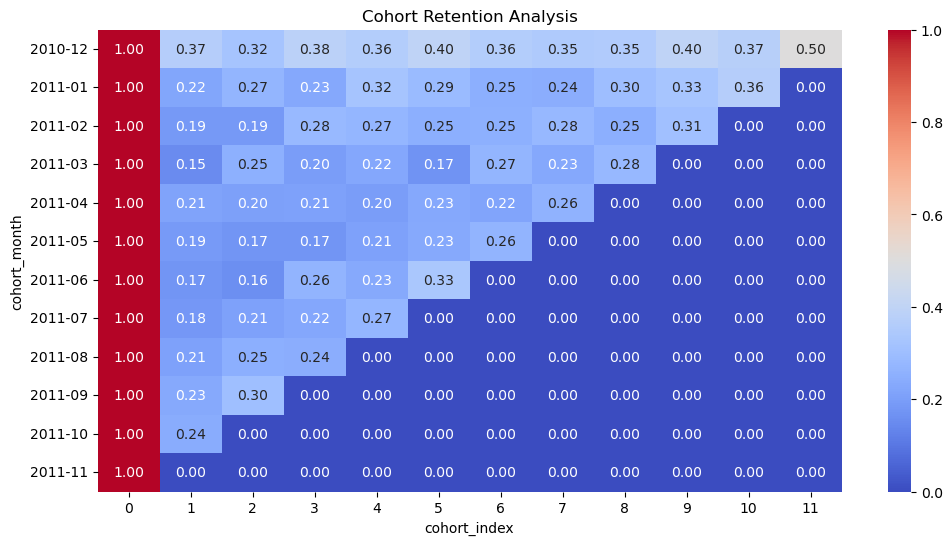

In [61]:
#Cohort Analysis
df_cohort = df_sales[['CustomerID', 'InvoiceDate']].copy()

df_cohort['sale_month'] = df_cohort['InvoiceDate'].dt.to_period('M')

df_cohort['cohort_month'] = df_cohort.groupby('CustomerID')['sale_month'].transform('min')

df_cohort['cohort_index'] = (
    (df_cohort['sale_month'].dt.year - df_cohort['cohort_month'].dt.year) * 12 +
    (df_cohort['sale_month'].dt.month - df_cohort['cohort_month'].dt.month)
)

# Pivot table
df_cohort_trend = df_cohort.pivot_table(
    index='cohort_month',
    columns='cohort_index',
    values='CustomerID',
    aggfunc='nunique',
    fill_value=0
)

# Retention
df_retention = df_cohort_trend.divide(df_cohort_trend[0], axis=0)

# Retention Heatmap
plt.figure(figsize=(12,6))
sns.heatmap(df_retention, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Cohort Retention Analysis")
plt.show()


In [46]:
# Exporting the dataframes into one Excel file (different sheets)
with pd.ExcelWriter(file_analysis,engine='openpyxl',mode='a',if_sheet_exists='replace') as writer:
    df_orders.to_excel(writer, sheet_name='Orders', index=False)
    df_rfm.to_excel(writer, sheet_name='RFM', index=False)
    df_retention.to_excel(writer, sheet_name='Retention', index=False)

## Insights
1. The overall revenue trend shows consistent growth over time.
2. There are 361 customers in the “At Risk” segment, indicating a need for targeted retention strategies.
3. Most cohorts experience a sharp decline after the first month, suggesting potential issues with onboarding or the initial purchase experience.